## Modeling Flow

 1. Load processed data

 2. Add sentiment feature

 3. TF-IDF vectorization

 4. Combine Tf-Idf and Sentiment feature

 5. Train Logistic Regression

 6. Train SVM

 7. Train XGBoost (for comparison)

 8. Saving Models

In [3]:
import pandas as pd
import numpy as np

### Installing TextBlob 

In [4]:
!pip install textblob
!python -m textblob.download_corpora

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\smrts\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\smrts\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\smrts\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\smrts\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\smrts\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\smrts\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

# 1. Load Dataset 

In [5]:
import pandas as pd

train_df = pd.read_csv("../data/train_processed.csv")
val_df = pd.read_csv("../data/val_processed.csv")
test_df = pd.read_csv("../data/test_processed.csv")

In [6]:
print(test_df.shape)
print(test_df.columns)
test_df.head()

(399976, 4)
Index(['label', 'text', 'clean_text', 'llm_text'], dtype='object')


,label,text,clean_text,llm_text
0,1,Great CD My lovely Pat has one of the GREAT vo...,great cd lovely pat one great voice generation...,Great CD My lovely Pat has one of the GREAT vo...
1,1,One of the best game music soundtracks - for a...,one best game music soundtrack game didnt real...,One of the best game music soundtracks - for a...
2,0,Batteries died within a year ... I bought this...,battery died within year bought charger jul wo...,Batteries died within a year ... I bought this...
3,1,"works fine, but Maha Energy is better Check ou...",work fine maha energy better check maha energy...,"works fine, but Maha Energy is better Check ou..."
4,1,Great for the non-audiophile Reviewed quite a ...,great nonaudiophile reviewed quite bit combo p...,Great for the non-audiophile Reviewed quite a ...


# 2. Add Sentiment 

#### 2.1 Import TextBlob

In [8]:
from textblob import TextBlob

#### 2.2 Sentiment feature method

In [9]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

#### 2.3 Applying Sentiment

In [10]:
train_df["sentiment"] = train_df["text"].apply(get_sentiment)
val_df["sentiment"] = val_df["text"].apply(get_sentiment)
test_df["sentiment"] = test_df["text"].apply(get_sentiment)

#### 2.4 Check Output

In [11]:
train_df["sentiment"].head()
train_df["sentiment"].describe()

count    79994.000000
mean         0.158216
std          0.248574
min         -1.000000
25%          0.003125
50%          0.158766
75%          0.311995
max          1.000000
Name: sentiment, dtype: float64

#### 2.5 Visualising 

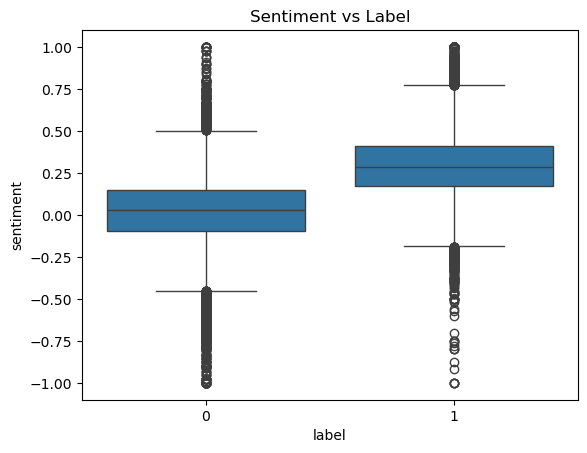

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="label", y="sentiment", data=train_df)
plt.title("Sentiment vs Label")
plt.show()

#### 2.6 Saving dataset with Sentiment Feature

In [13]:
train_df.to_csv("../data/train_with_sentiment.csv", index=False)
val_df.to_csv("../data/val_with_sentiment.csv", index=False)
test_df.to_csv("../data/test_with_sentiment.csv", index=False)

# 3. Tf-Idf Vectorization

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [50]:
tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range = (1,2)
)

In [16]:
#checking for missing values in test_df
test_df["clean_text"].isna().sum()

1

In [17]:
test_df = test_df.dropna(subset=["clean_text"])

In [18]:
test_df["clean_text"].isna().sum()

0

In [19]:
test_df = test_df.reset_index(drop=True)

In [20]:
X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
X_val_tfidf = tfidf.transform(val_df["clean_text"])
X_test_tfidf = tfidf.transform(test_df["clean_text"])

# 4. Combining Tf-Idf and Sentiment 

In [51]:
from scipy.sparse import hstack


In [52]:
X_train = hstack([
    X_train_tfidf,
    train_df[["sentiment"]].values
])

X_val = hstack([
    X_val_tfidf,
    val_df[["sentiment"]].values
])

X_test = hstack([
    X_test_tfidf,
    test_df[["sentiment"]].values
])

In [23]:
# Labels
y_train = train_df["label"]
y_val = val_df["label"]
y_test = test_df["label"]

# 5. Logistic Regression (as Baseline Model)

In [26]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [27]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

Logistic Regression Accuracy: 0.8833441672083604
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     10002
           1       0.88      0.88      0.88      9997

    accuracy                           0.88     19999
   macro avg       0.88      0.88      0.88     19999
weighted avg       0.88      0.88      0.88     19999



# 6. SVM (Main Model)

In [30]:
from sklearn.svm import LinearSVC

In [31]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)

print("SVM Accuracy:", accuracy_score(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

SVM Accuracy: 0.8825941297064853
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     10002
           1       0.88      0.88      0.88      9997

    accuracy                           0.88     19999
   macro avg       0.88      0.88      0.88     19999
weighted avg       0.88      0.88      0.88     19999



# 7. XgBoost (Comparative Model)

In [49]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_final, y_train)

y_pred_xgb = xgb_model.predict(X_val_final)

print("XGBoost Accuracy:", accuracy_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))

XGBoost Accuracy: 0.8306915345767288
              precision    recall  f1-score   support

           0       0.83      0.83      0.83     10002
           1       0.83      0.83      0.83      9997

    accuracy                           0.83     19999
   macro avg       0.83      0.83      0.83     19999
weighted avg       0.83      0.83      0.83     19999



# 8. Saving Models

In [54]:
import joblib

joblib.dump(tfidf, "../models/tfidf.pkl")
joblib.dump(lr, "../models/lr.pkl")
joblib.dump(svm_model, "../models/svm_model.pkl")
joblib.dump(xgb_model, "../models/xgb_model.pkl")

['../models/xgb_model.pkl']

In [55]:
import os
print(os.listdir("../models"))

['lr.pkl', 'svm_model.pkl', 'tfidf.pkl', 'xgb_model.pkl']
